<a href="https://colab.research.google.com/github/koherrera97/kevin_INFO4670_Spring2026/blob/main/Assignment_2_1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [2]:
# Write your code here

from google.colab import files
uploaded = files.upload()


Saving Assignment 2 dataset (1).csv to Assignment 2 dataset (1) (1).csv


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

Dataset Shape: (18254, 14)

Columns:
 Index(['Column 1', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='object')

===== Distribution of REGION =====
                     Count  Percentage (%)
region                                    
WestTexNewMexico       340            1.86
Albany                 338            1.85
BaltimoreWashington    338            1.85
Boise                  338            1.85
Boston                 338            1.85
Atlanta                338            1.85
California             338            1.85
Charlotte              338            1.85
Chicago                338            1.85
CincinnatiDayton       338            1.85
Columbus               338            1.85
DallasFtWorth          338            1.85
Denver                 338            1.85
Detroit                338            1.85
GrandRapids            338         

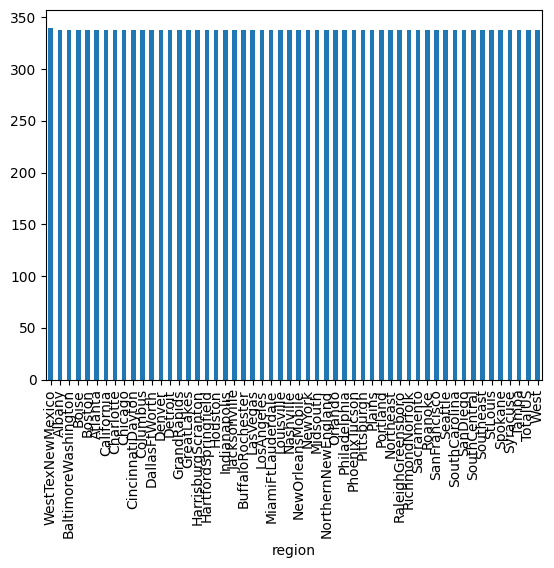

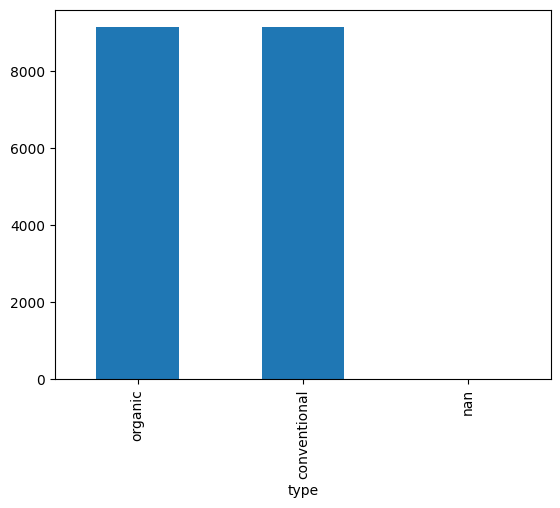

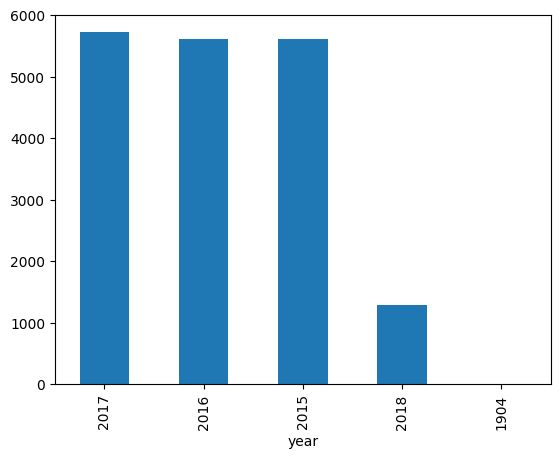

In [9]:
# Write your code here


import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# -----------------------------
# Basic Dataset Overview
# -----------------------------
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

# -----------------------------
# Distribution Analysis
# -----------------------------
columns_to_analyze = ['region', 'type', 'year']

for col in columns_to_analyze:
    print(f"\n===== Distribution of {col.upper()} =====")

    # Count and percentage
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(normalize=True, dropna=False) * 100

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage (%)": percentages.round(2)
    })

    print(distribution)

    # Plot distribution
    plt.figure()
    counts.plot(kind='bar')
    plt.title


1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [10]:
# Write your code here
import pandas as pd

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# -----------------------------------
# 1️⃣ Check for Duplicate Rows
# -----------------------------------

# Total number of duplicate rows
duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

# -----------------------------------
# 2️⃣ Check for Missing Values
# -----------------------------------

# Count missing values per column
missing_values = df.isnull().sum()

print("\nMissing Values Per Column:")
print(missing_values)

# -----------------------------------
# 3️⃣ Optional: Percentage of Missing Values
# -----------------------------------

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage Per Column:")
print(missing_percentage.round(2))


# -----------------------------------
# 4️⃣ Example Handling (Not Executed)
# -----------------------------------

# OPTION A: Drop duplicate rows
# df = df.drop_duplicates()

# OPTION B: Drop rows with missing values
# df = df.dropna()

# OPTION C: Impute missing numeric values with median
# numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
# df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# OPTION D: Impute missing categorical values with mode
# categorical_cols = df.select_dtypes(include=['object']).columns
# for col in categorical_co_


Total Duplicate Rows: 2

Missing Values Per Column:
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64

Missing Value Percentage Per Column:
Column 1        0.00
Date            0.00
AveragePrice    0.00
Total Volume    0.01
4046            0.01
4225            0.01
4770            0.01
Total Bags      0.01
Small Bags      0.01
Large Bags      0.01
XLarge Bags     0.01
type            0.01
year            0.00
region          0.00
dtype: float64


1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [12]:
# Write your code here
import pandas as pd

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# Print number of rows and columns
rows, columns = df.shape



#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [14]:
# Write your code here
import pandas as pd

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# -----------------------------------
# 1️⃣ Remove "Column 1"
# -----------------------------------
df = df.drop(columns=["Column 1"])

# Verify column removal
print("Columns after dropping 'Column 1':")
print(df.columns)

# -----------


Columns after dropping 'Column 1':
Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='object')


2.2 Check for duplicate values and remove them.

In [16]:
# Write your code here
import pandas as pd

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# -----------------------------------
# 1️⃣ Check for Duplicate Rows
# -----------------------------------
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows before removal:", duplicate_count)

# -----------------------------------
# 2️⃣ Remove Duplicate Rows
# -----------------------------------
df = df.drop_duplicates()

# ------------------------------


Number of duplicate rows before removal: 2


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [18]:
# Write your code here

import pandas as pd

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# -----------------------------------
# 1️⃣ Check Missing Values
# -----------------------------------
print("Missing values per column:\n")
print(df.isnull().sum())

# -----------------------------------
# 2️⃣ Remove Rows with Too Many Missing Values
# (If more than 50% of the row is missing)
# -----------------------------------

threshold = int(df.shape[1] * 0.5)  # 50% threshold
df = df.dropna(thresh=threshold)

print("\nShape after removing rows with excessive missing values:", df.shape)

# -----------------------------------
# 3️⃣ Replace Remaining Missing Values
# Using Median Within Each Region
# -----------------------------------

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing values with regional median
for col in numeric_cols:
    df[col] = df.groupby('region')[col].transform(
        lambda x: x.fillna(x.median())
    )

# -----------------------------------
# 4️⃣ Verify Remaining Missing Values
# -----------------------------------

print("\nMissing values after treatment:\n")
print(df.isnull().sum())


Missing values per column:

Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64

Shape after removing rows with excessive missing values: (18253, 14)

Missing values after treatment:

Column 1        0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


Correlation Matrix:

              AveragePrice  Total Volume      4046      4225      4770  \
AveragePrice      1.000000     -0.192774 -0.208335 -0.172951 -0.179463   
Total Volume     -0.192774      1.000000  0.977863  0.974181  0.872203   
4046             -0.208335      0.977863  1.000000  0.926111  0.833390   
4225             -0.172951      0.974181  0.926111  1.000000  0.887856   
4770             -0.179463      0.872203  0.833390  0.887856  1.000000   
Total Bags       -0.177109      0.963047  0.920057  0.905788  0.792316   
Small Bags       -0.174751      0.967239  0.925281  0.916032  0.802734   
Large Bags       -0.172960      0.880641  0.838646  0.810017  0.698473   
XLarge Bags      -0.117610      0.747159  0.699379  0.688811  0.679863   
year              0.064343      0.014033  0.003606 -0.006012 -0.026403   

              Total Bags  Small Bags  Large Bags  XLarge Bags      year  
AveragePrice   -0.177109   -0.174751   -0.172960    -0.117610  0.064343  
Total Volume    

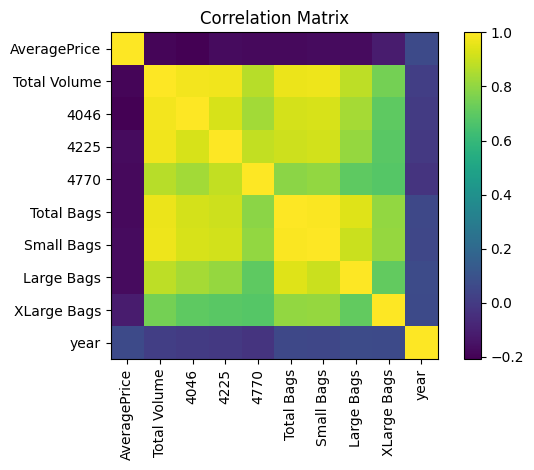


Highly Correlated Features (>|0.9|):
{'4046', '4225', 'Small Bags', 'Total Bags', 'Large Bags'}

Model Performance Comparison (R² Score)
Using All Features:  0.0133
Using Reduced Features:  0.0052


In [23]:
# Write your code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("Assignment 2 dataset (1) (1).csv")

# Drop unnecessary column if it exists
if "Column 1" in df.columns:
    df = df.drop(columns=["Column 1"])

# Keep only numeric variables
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Remove missing values for modeling
numeric_df = numeric_df.dropna()

# -----------------------------------
# 1️⃣ Correlation Matrix
# -----------------------------------
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:\n")
print(correlation_matrix)

# Plot correlation heatmap (single plot)
plt.figure()
plt.imshow(correlation_matrix)
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)
plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

# -----------------------------------
# 2️⃣ Identify Highly Correlated Features
# (Correlation > 0.9)
# -----------------------------------
high_corr = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            colname = correlation_matrix.columns[i]
            high_corr.append(colname)

print("\nHighly Correlated Features (>|0.9|):")
print(set(high_corr))

# -----------------------------------
# 3️⃣ Compare Model Accuracy
# -----------------------------------

# Define target variable
y = numeric_df["AveragePrice"]

# Model 1: Use ALL numeric features
X_all = numeric_df.drop(columns=["AveragePrice"])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train, y_train)
y_pred_all = model_all.predict(X_test)

r2_all = r2_score(y_test, y_pred_all)

# Model 2: Remove highly correlated features
X_reduced = X_all.drop(columns=list(set(high_corr)))

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_reduced = LinearRegression()
model_reduced.fit(X_train2, y_train2)
y_pred_reduced = model_reduced.predict(X_test2)

r2_reduced = r2_score(y_test2, y_pred_reduced)

print("\nModel Performance Comparison (R² Score)")
print("Using All Features: ", round(r2_all, 4))
print("Using Reduced Features: ", round(r2_reduced, 4))



#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

In [25]:
# Write your code here

import pandas as pd

# Load your dataset
# Replace 'your_dataset.csv' with your file path
df = pd.read_csv('Assignment 2 dataset (1) (1).csv')

# Separate continuous and categorical variables
continuous_vars = df.select_dtypes(include=['float64', 'int64']).columns
categorical_vars = df.select_dtypes(include=['object', 'category']).columns

print("=== Continuous Variables ===\n")
for col in continuous_vars:
    print(f"Variable: {col}")
    print(f"  Range: ({df[col].min()}, {df[col].max()})")
    print(f"  Mean: {df[col].mean()}")
    print(f"  Median: {df[col].median()}")
    print(f"  Distribution (value counts):\n{df[col].value_counts(bins=10, sort=False)}\n")

print("=== Categorical Variables ===\n")
for col in categorical_vars:
    print(f"Variable: {col}")
    print(f"  Unique values: {df[col].unique()}")
    print(f"  Counts:\n{df[col].value_counts()}\n")


=== Continuous Variables ===

Variable: Column 1
  Range: (0, 52)
  Mean: 24.228059603374604
  Median: 24.0
  Distribution (value counts):
(-0.053, 5.2]    2592
(5.2, 10.4]      2164
(10.4, 15.6]     1729
(15.6, 20.8]     1620
(20.8, 26.0]     1944
(26.0, 31.2]     1620
(31.2, 36.4]     1620
(36.4, 41.6]     1620
(41.6, 46.8]     1620
(46.8, 52.0]     1725
Name: count, dtype: int64

Variable: AveragePrice
  Range: (0.44, 3.25)
  Mean: 1.4060731894379315
  Median: 1.37
  Distribution (value counts):
(0.436, 0.721]     331
(0.721, 1.002]    2632
(1.002, 1.283]    4824
(1.283, 1.564]    4506
(1.564, 1.845]    3415
(1.845, 2.126]    1674
(2.126, 2.407]     598
(2.407, 2.688]     177
(2.688, 2.969]      86
(2.969, 3.25]       11
Name: count, dtype: int64

Variable: Total Volume
  Range: (84.56, 62505646.52)
  Mean: 850460.9394757026
  Median: 107306.08
  Distribution (value counts):
(-62421.003, 6250640.756]       17883
(6250640.756, 12501196.952]       201
(12501196.952, 18751753.148]     

3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [26]:
# Write your code here

import pandas as pd

# Load the dataset
df = pd.read_csv('Assignment 2 dataset (1) (1).csv')

# Make sure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 1️⃣ Find the earliest date
earliest_date = df['Date'].min()
print(f"Earliest Date in Dataset: {earliest_date.date()}")

# 2️⃣ Filter data from earliest date up to 2010
# Note: Assuming you mean 'up to 2010' inclusive, so before 2011
data_up_to_2010 = df[df['Date'].dt.year <= 2010]

print(f"\nNumber of records up to 2010: {len(data_up_to_2010)}")
print(f"Data from earliest date to 2010:\n{data_up_to_2010.head()}")

# 3️⃣ Comment: check if the earliest data point looks reasonable
earliest_record = df[df['Date'] == earliest_date]
print(f"\nEarliest record:\n{earliest_record}")

# Optional: decide if you want to remove the earliest data point
# df = df[df['Date'] > earliest_date]  # Uncomment to remove


Earliest Date in Dataset: 1904-01-21

Number of records up to 2010: 1
Data from earliest date to 2010:
       Column 1       Date  AveragePrice  Total Volume     4046     4225  \
18250         9 1904-01-21          1.87      13766.76  1191.92  2452.79   

         4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18250  727.94     9394.11      9351.8       42.31          0.0  organic  1904   

                 region  
18250  WestTexNewMexico  

Earliest record:
       Column 1       Date  AveragePrice  Total Volume     4046     4225  \
18250         9 1904-01-21          1.87      13766.76  1191.92  2452.79   

         4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18250  727.94     9394.11      9351.8       42.31          0.0  organic  1904   

                 region  
18250  WestTexNewMexico  


3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [27]:
# Write your code here

import pandas as pd

# Load the dataset
df = pd.read_csv('Assignment 2 dataset (1) (1).csv')

# Make sure 'AveragePrice' exists
if 'AveragePrice' in df.columns and 'region' in df.columns:
    # 1️⃣ Find the highest value in 'AveragePrice'
    max_price = df['AveragePrice'].max()
    print(f"Highest AveragePrice: {max_price}")

    # 2️⃣ Find the region(s) corresponding to this highest price
    regions_max_price = df[df['AveragePrice'] == max_price]['region'].unique()
    print(f"Region(s) with highest price: {regions_max_price}")

    # 3️⃣ Optional: show full record(s) with highest price
    print(f"\nRecord(s) with highest AveragePrice:\n{df[df['AveragePrice'] == max_price]}")

else:
    print("Columns 'AveragePrice' or 'region' not found in the dataset.")


Highest AveragePrice: 3.25
Region(s) with highest price: ['SanFrancisco']

Record(s) with highest AveragePrice:
       Column 1        Date  AveragePrice  Total Volume     4046      4225  \
14125         8  10-30-2016          3.25      16700.94  2325.93  11142.85   

       4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
14125   0.0     3232.16     3232.16         0.0          0.0  organic  2016   

             region  
14125  SanFrancisco  


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [28]:
# Write your code here

import pandas as pd

# Load the dataset
df = pd.read_csv('Assignment 2 dataset (1) (1).csv')

# Make sure the columns exist
if 'Total Volume' in df.columns and 'region' in df.columns:
    # 1️⃣ Find the highest Total Volume
    max_volume = df['Total Volume'].max()
    print(f"Highest Total Volume: {max_volume}")

    # 2️⃣ Find the region(s) corresponding to this highest volume
    regions_max_volume = df[df['Total Volume'] == max_volume]['region'].unique()
    print(f"Region(s) with highest Total Volume: {regions_max_volume}")

    # 3️⃣ Optional: show full record(s) with highest volume
    print(f"\nRecord(s) with highest Total Volume:\n{df[df['Total Volume'] == max_volume]}")
else:
    print("Columns 'Total Volume' or 'region' not found in the dataset.")


Highest Total Volume: 62505646.52
Region(s) with highest Total Volume: ['TotalUS']

Record(s) with highest Total Volume:
      Column 1      Date  AveragePrice  Total Volume        4046         4225  \
9097         7  2-4-2018          0.87   62505646.52  21620180.9  20445501.03   

            4770   Total Bags  Small Bags  Large Bags  XLarge Bags  \
9097  1066830.22  19373134.37  13384586.8  5719096.61    269450.96   

              type  year   region  
9097  conventional  2018  TotalUS  
